# 🌳 Decision Trees with Drug200 Dataset

### 📊 About the Dataset
Imagine you are a **medical researcher** compiling data for a study.  
You have collected data about a group of patients, all suffering from the same illness.  
During their treatment, each patient responded to one of **five medications**:  
- 💊 Drug A  
- 💊 Drug B  
- 💊 Drug C  
- 💊 Drug X  
- 💊 Drug Y  

The dataset contains the following **features**:  
- 👵 Age  
- 🚻 Sex  
- ❤️ Blood Pressure (BP)  
- 🧬 Cholesterol  
- ⚖️ Na_to_K ratio (sodium to potassium)  

The **target variable** is the **drug** that each patient responded to.  

---

### 🎯 Objective
The goal is to **build a Decision Tree model** to predict the most appropriate drug for a **new patient** based on their features.  

---

### 🔍 Why Decision Trees?
- 🌳 Easy to interpret and visualize  
- ✅ Handles both numerical and categorical data  
- 🔄 Works well for **multiclass classification** problems  
- 🩺 Provides clear rules for medical decision-making  

---

### 🧪 Workflow
1. 📥 Load and explore the dataset  
2. 🔧 Preprocess categorical features (Sex, BP, Cholesterol)  
3. ✂️ Split data into training and testing sets  
4. 🌳 Train a **Decision Tree classifier**  
5. 📊 Evaluate performance using accuracy  
6. 👀 Visualize the decision tree for interpretability  

---

### ✅ Use Case
This dataset is a **sample multiclass classification problem**.  
By training a Decision Tree, we can:  
- Predict the class (drug type) of an **unknown patient**  
- Provide a **drug recommendation** for a **new patient**  

---

✨ In short:  
The **Drug200 dataset** is a great example of how **Decision Trees** can be applied in healthcare to make predictions and assist medical research.  


In [1]:
# Import libraries
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
import warnings

In [2]:
# Import data
path= 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
my_data = pd.read_csv(path)
my_data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
# Data analysis and preprocessing
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [ ]:
# This tells that 4 out of 6 features are non-numeric and need to be converted to numeric.
# We can use LabelEncoder to convert these columns to numeric.
# 'Sex' : M -> 1, F -> 0
# 'BP' : HIGH -> 0, LOW -> 1, NORMAL -> 2
# 'Cholesterol' : HIGH -> 0, NORMAL -> 1
label_encoder = LabelEncoder()
my_data['Sex'] = label_encoder.fit_transform(my_data['Sex'])
my_data['BP'] = label_encoder.fit_transform(my_data['BP'])
my_data['Cholesterol'] = label_encoder.fit_transform(my_data['Cholesterol'])
my_data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY
...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC
196,16,1,1,0,12.006,drugC
197,52,1,2,0,9.894,drugX
198,23,1,2,1,14.020,drugX


In [5]:
# Checking for missing values
my_data.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [13]:
# Evaluate the correlation of the target variable with the input features
# Map the target variable 'Drug' to numeric values
custom_map = {'drugA': 0, 'drugB': 1, 'drugC': 2, 'drugX': 3, 'drugY': 4}
my_data['Drug_num'] = my_data['Drug'].map(custom_map)
my_data
# Use the corr() method to find the correlation of the input features with the target variable
# Identify the features most significantly affecting the target variable
my_data.drop('Drug',axis=1).corr()['Drug_num']
  

Age           -0.004828
Sex           -0.098573
BP             0.372868
Cholesterol    0.055629
Na_to_K        0.589120
Drug_num       1.000000
Name: Drug_num, dtype: float64

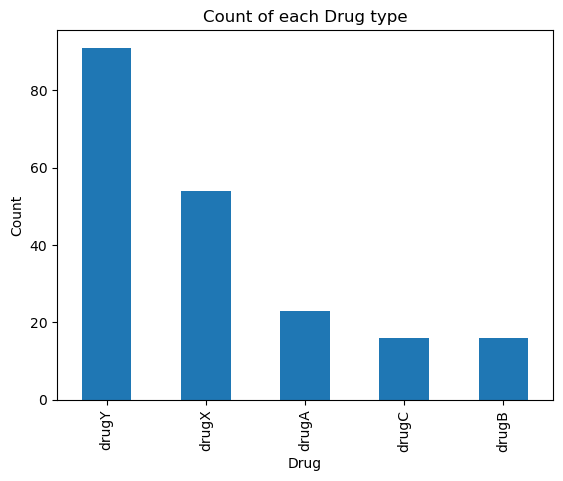

In [14]:
# We can understand the distrubution of the dara set by plotting the count of the records for each value of the target variable
my_data['Drug'].value_counts().plot(kind='bar')
plt.xlabel('Drug')
plt.ylabel('Count')
plt.title('Count of each Drug type')
plt.show()


In [15]:
# Modeling with Decision Trees
# First split the data set into training and testing data sets.
y = my_data['Drug']
X = my_data.drop(['Drug','Drug_num'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32)
# Create the Decision Tree classifier object
drugTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)
# Fit the model
drugTree.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [16]:
# Evaluate the model
tree_predictions = drugTree.predict(X_test)
# Model Accuracy, how often is the classifier correct?
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_test, tree_predictions))

DecisionTrees's Accuracy:  0.9833333333333333


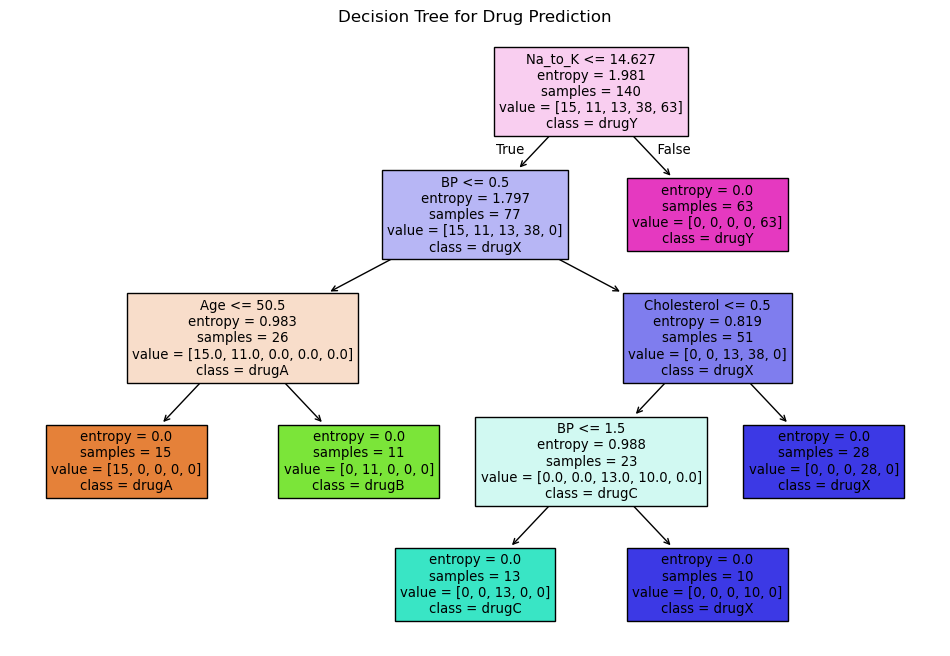

In [20]:
# Visualize the decision tree
plt.figure(figsize=(12,8))
plot_tree(drugTree, feature_names=X.columns, class_names=list(custom_map.keys()), filled=True)
plt.title('Decision Tree for Drug Prediction')
plt.show()

In [ ]:
# Identify the decisions creteria for all classes
# Extract the decision rules from the trained decision tree
# Drug A : Na_to_Ka <= 14.627, BP = High, Age <= 50.5
# Drug B : Na_to_Ka <= 14.627, BP = High, Age > 50.5
# Drug C : Na_to_Ka <= 14.627, BP = Low, Cholesterol <= High
# Drug X : Na_to_Ka <= 14.627, BP = Normal, Cholesterol = High
# Drug Y : Na_to_Ka > 14.627
from sklearn.tree import export_text
tree_rules = export_text(drugTree, feature_names=list(X.columns))
print(tree_rules)   

|--- Na_to_K <= 14.63
|   |--- BP <= 0.50
|   |   |--- Age <= 50.50
|   |   |   |--- class: drugA
|   |   |--- Age >  50.50
|   |   |   |--- class: drugB
|   |--- BP >  0.50
|   |   |--- Cholesterol <= 0.50
|   |   |   |--- BP <= 1.50
|   |   |   |   |--- class: drugC
|   |   |   |--- BP >  1.50
|   |   |   |   |--- class: drugX
|   |   |--- Cholesterol >  0.50
|   |   |   |--- class: drugX
|--- Na_to_K >  14.63
|   |--- class: drugY



In [22]:
# If the max depth is reduced to 3, how would the performance of the model be affected?
# Create the Decision Tree classifier object with max_depth = 3
drugTree2 = DecisionTreeClassifier(criterion="entropy", max_depth = 3)
# Fit the model
drugTree2.fit(X_train,y_train)
# Evaluate the model
tree2_predictions = drugTree2.predict(X_test)
# Model Accuracy, how often is the classifier correct?
print("DecisionTrees's Accuracy with max_depth=3: ", metrics.accuracy_score(y_test, tree2_predictions))

DecisionTrees's Accuracy with max_depth=3:  0.8166666666666667
